## Exploratory Data Analysys

In [6]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns

In [7]:
# Read file and visualizing the first rows
original_data = pd.read_csv('..\\data\\raw\\healthcare_dataset.csv')
original_data.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
0,Bobby Jackson,19,Female,AB+,Infections,2024-01-31,Matthew Smith,Northwestern Memorial Hospital,Blue Cross,2212.272701,328,Emergency,2024-02-07,Azithromycin,Normal,7
1,Leslie Terry,15,Female,B-,Flu,2019-08-20,Samantha Davies,UI Health (University of Illinois Hospital),UnitedHealthcare,3185.161388,265,Emergency,2019-08-22,Tamiflu,Abnormal,2
2,Danny Smith,50,Female,A+,Cancer,2022-09-22,Tiffany Mitchell,UI Health (University of Illinois Hospital),Blue Cross,72055.214065,205,Elective,2022-10-30,Cisplatin,Inconclusive,38
3,Andrew Watts,24,Female,O+,Asthma,2020-11-18,Kevin Wells,UI Health (University of Illinois Hospital),Aetna,4092.601229,450,Elective,2020-11-19,Prednisone,Normal,1
4,Adrienne Bell,80,Female,A+,Heart Disease,2022-09-19,Kathleen Hanna,Northwestern Memorial Hospital,Cigna,47985.660254,458,Routine,2022-10-27,Beta-blockers,Inconclusive,38


In [8]:
original_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
 15  Length of Stay      55500 non-null  int64  
dtypes: float64(1), 

- Date columns are stored as strings, conversion to datetime is needed.
- The data already brings lenght of stay calculated, i'll calculate by subtracting the date od admission from the date of discharge to check consistency
- Remove columns thai is likely not useful for modeling 

In [9]:
# Convert 'Date of Admission' and 'Discharge Date' to datetime
original_data['Date of Admission'] = pd.to_datetime(original_data['Date of Admission'], errors='coerce')
original_data['Discharge Date'] = pd.to_datetime(original_data['Discharge Date'], errors='coerce')

In [10]:
# Create a new column 'Calculated Length of Stay' by calculating the difference in days between 'Discharge Date' and 'Date of Admission' and
#  comparing it with the 'Length of Stay' column
original_data['Calculated Length of Stay'] = (original_data['Discharge Date'] - original_data['Date of Admission']).dt.days
differences = (original_data['Calculated Length of Stay'] != original_data['Length of Stay']).sum()
print('Differences between calculated and original Length of Stay:', differences)

Differences between calculated and original Length of Stay: 0


In [15]:
# Remove the 'Calculated Length of Stay' column and trivial text columns
analysis_data = original_data.copy()
analysis_data = analysis_data.drop(columns=['Calculated Length of Stay', 'Name','Date of Admission','Doctor','Hospital','Billing Amount','Room Number', 'Discharge Date'])
analysis_data.head()

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Admission Type,Medication,Test Results,Length of Stay
0,19,Female,AB+,Infections,Blue Cross,Emergency,Azithromycin,Normal,7
1,15,Female,B-,Flu,UnitedHealthcare,Emergency,Tamiflu,Abnormal,2
2,50,Female,A+,Cancer,Blue Cross,Elective,Cisplatin,Inconclusive,38
3,24,Female,O+,Asthma,Aetna,Elective,Prednisone,Normal,1
4,80,Female,A+,Heart Disease,Cigna,Routine,Beta-blockers,Inconclusive,38


In [16]:
# Check for missing values
print(analysis_data.isnull().sum())

Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Insurance Provider    0
Admission Type        0
Medication            0
Test Results          0
Length of Stay        0
dtype: int64


There aren't missing values

In [17]:
analysis_data.describe()

,Age,Length of Stay
count,55500.000000,55500.000000
mean,48.001622,17.841009
std,21.105827,20.272294
min,5.000000,1.000000
25%,32.000000,4.000000
50%,50.000000,8.000000
75%,65.000000,28.000000
max,90.000000,89.000000


In [19]:
analysis_data['Length of Stay'][analysis_data['Length of Stay'] > 50].count()

np.int64(5148)

In [18]:
analysis_data['Medical Condition'].value_counts()

Medical Condition
Flu              7046
Diabetes         7005
Obesity          6994
Cancer           6940
Asthma           6908
Heart Disease    6900
Alzheimer’s      6861
Infections       6846
Name: count, dtype: int64

In [ ]:
#analysis_data.groupby('Gender')['Length of Stay'].mean() # not significant variation between genders
#  analysis_data.groupby('Admission Type')['Length of Stay'].mean() # only small differences between the types of admission
analysis_data.groupby('Medical Condition')['Length of Stay'].mean() # Alzheimer's, Cancer and Heart Disease have much higher average length of stay

Medical Condition
Alzheimer’s      54.417286
Asthma            3.503619
Cancer           36.543804
Diabetes          8.063098
Flu               2.504967
Heart Disease    26.860580
Infections        5.521911
Obesity           5.966400
Name: Length of Stay, dtype: float64

<Axes: xlabel='Length of Stay', ylabel='Count'>

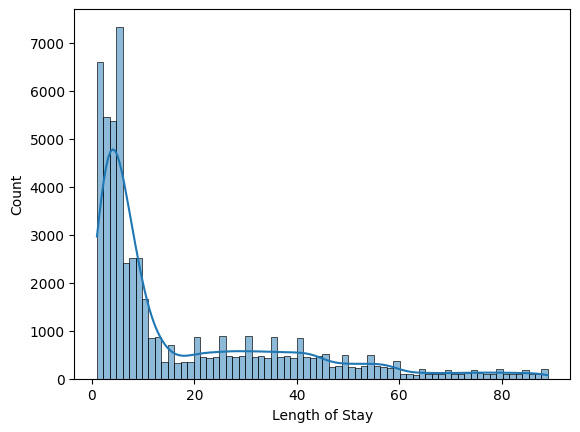

In [23]:
# plot the distribution of length of stay
sns.histplot(analysis_data['Length of Stay'], kde=True)

<Axes: xlabel='Length of Stay'>

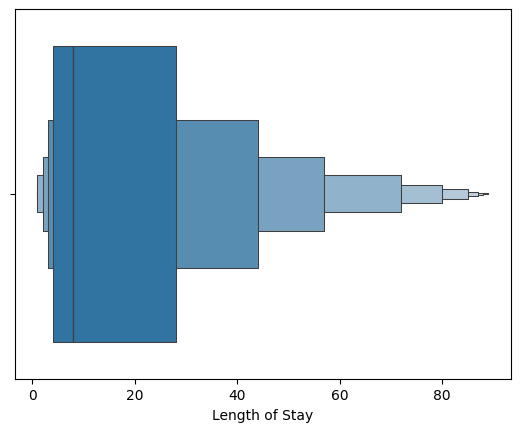

In [26]:
#sns.boxplot(x=analysis_data['Length of Stay'])
sns.boxenplot(x=analysis_data['Length of Stay'])

### The distribution is positively skewed, which is expected for Length of Stay (LOS). One of the greatest challenges in healthcare management is minimizing LOS. Achieving this indicates high-quality healthcare interventions, which not only maximize patient quality of life and satisfaction but also increase bed turnover, allowing the facility to treat more patients